# Causal Forest DML & Policy Learning — Optimal Scholarship Assignment

This notebook extends notebooks 3 (Double Post-LASSO) and 4 (Double ML) by:

1. Estimating **heterogeneous treatment effects** (CATE) of scholarships on **dropout probability** using **CausalForestDML** (Wager & Athey, 2018)
2. Designing an **optimal scholarship allocation policy** under budget constraints (Kitagawa & Tetenov, 2018; Athey & Wager, 2021)

**Sample:** Graduate + Dropout students only (`df_resolved`, n ≈ 3,630)
**Treatment:** Scholarship holder (binary)
**Outcome:** Y = 1 if Dropout — same convention as notebooks 3 and 4

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import (
    GradientBoostingRegressor, GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from econml.dml import CausalForestDML

sns.set_theme(style="whitegrid")
np.random.seed(42)


## 1. Data Loading & Sample Construction

We load the UCI dataset and split into:
- `df_resolved`: students with a known outcome (Graduate or Dropout) — used for causal estimation
- `df_enrolled`: students still enrolled — used to apply the policy

**Outcome: Dropout** (`Y = 1 if Dropout, 0 if Graduate`) — same convention as notebooks 3 and 4.
Negative CATE = scholarship reduces dropout probability.

### Variable selection (aligned with DAG — `theoretical/DAG.ipynb`)

| Group | Variables | Role | Justification (DAG) |
|---|---|---|---|
| Socio-demo | 11 vars | ✅ `W_confounders` | → Scholarship **and** → Target |
| Macro | Unemployment, Inflation, GDP | ✅ `W_confounders` | → Scholarship (via financial resources) |
| Academic pre-enrolment | Application mode, Course, etc. | ⚠️ `W_precision` only | → Target only (not → Scholarship) |
| **Mediators** | Debtor, Tuition fees up to date | ❌ Excluded | On causal path Scholarship → Target |
| **Post-treatment** | Curricular units (sem 1 & 2) | ❌ Excluded | Measured after scholarship assignment |

In [7]:
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=697)
X_data = dataset.data.features
y_data = dataset.data.targets

df = pd.concat([X_data, y_data], axis=1)
df.columns = df.columns.str.strip()

print(f"Full dataset: {df.shape[0]} students, {df.shape[1]} features")
print(f"\nTarget distribution:")
print(df['Target'].value_counts())

Full dataset: 4424 students, 37 features

Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [8]:
treatment = 'Scholarship holder'

# ── Outcome : DROPOUT (1=Dropout, 0=Graduate) — same as notebooks 3 & 4 ────────
df['Dropout'] = (df['Target'] == 'Dropout').astype(int)

# ── W_confounders : TRUE confounders per DAG ─────────────────────────────────────
# Only variables with paths BOTH to Scholarship AND to Target
W_confounders = [
    # Socio-demographic (11 nodes → Scholarship holder AND → Target in DAG)
    'Marital Status', "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation",
    'Nacionality', 'Gender', 'Age at enrollment',
    'Displaced', 'Educational special needs', 'International',
    # Macroeconomic (→ Scholarship AND → Target via Debtor/Tuition in DAG)
    'Unemployment rate', 'Inflation rate', 'GDP',
]

# ── W_precision : pre-treatment predictors, NOT confounders ──────────────────────
# DAG: → Target only, no path to Scholarship holder
W_precision = [
    'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance', 'Previous qualification',
    'Previous qualification (grade)', 'Admission grade',
]

# W_all = W_confounders + W_precision → used for mu_0 baseline model (better prediction)
W_all = W_confounders + W_precision

# ── Sample construction ──────────────────────────────────────────────────────────
df_resolved = df[df['Target'].isin(['Graduate', 'Dropout'])].copy().reset_index(drop=True)
df_enrolled  = df[df['Target'] == 'Enrolled'].copy().reset_index(drop=True)

print(f"df_resolved (Graduate + Dropout): {len(df_resolved)} students")
print(f"  → Dropout rate:     {df_resolved['Dropout'].mean()*100:.1f}%")
print(f"  → Scholarship rate: {df_resolved[treatment].mean()*100:.1f}%")
print(f"\ndf_enrolled (Enrolled): {len(df_enrolled)} students")
print(f"  → Scholarship rate: {df_enrolled[treatment].mean()*100:.1f}%")
print(f"\nW_confounders ({len(W_confounders)} vars): {W_confounders}")
print(f"W_precision   ({len(W_precision)} vars): {W_precision}")

df_resolved (Graduate + Dropout): 3630 students
  → Dropout rate:     39.1%
  → Scholarship rate: 26.7%

df_enrolled (Enrolled): 794 students
  → Scholarship rate: 16.4%

W_confounders (14 vars): ['Marital Status', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Nacionality', 'Gender', 'Age at enrollment', 'Displaced', 'Educational special needs', 'International', 'Unemployment rate', 'Inflation rate', 'GDP']
W_precision   (7 vars): ['Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Admission grade']


## 2. CausalForestDML — Heterogeneous Treatment Effects (CATE)

**CausalForestDML** (Wager & Athey 2018 + Chernozhukov et al. 2018) estimates individual-level treatment effects:

$$\hat{\tau}(W_i) = \mathbb{E}[Y_i(1) - Y_i(0) \mid W_i]$$

where $Y = 1$ if **Dropout** (same as notebooks 3 & 4). **Negative CATE = scholarship reduces dropout.**

The algorithm uses **5-fold cross-fitting** to estimate nuisances $\hat{\ell}(W) = \mathbb{E}[Y|W]$ and $\hat{m}(W) = \mathbb{E}[D|W]$, then builds a causal forest on residuals.

**Nuisance models: GBR + GBC** — the best-performing pair from notebook 4 (lowest combined nuisance loss).

**W_confounders** = socio-demographic + macroeconomic only (true confounders per DAG).
Expected ATE ≈ −0.055 (consistent with notebook 4: scholarship reduces dropout by ~5.5 pp).

In [9]:
X_resolved = df_resolved[W_confounders].values
Y_res = df_resolved['Dropout'].values.astype(float)   # Y=1 if Dropout
D_res = df_resolved[treatment].values.astype(float)

est = CausalForestDML(
    model_y=GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42),
    model_t=GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42),
    discrete_treatment=True,
    n_estimators=1000,
    random_state=42,
    cv=5,
    verbose=0,
)
est.fit(Y_res, D_res, X=X_resolved)

tau_hat = est.effect(X_resolved).flatten()
df_resolved['tau_hat'] = tau_hat

print(f"CATE estimated for {len(tau_hat)} students")
print(f"  Mean CATE (≈ ATE):      {tau_hat.mean():+.4f}  (expected ≈ −0.055)")
print(f"  Std CATE:               {tau_hat.std():.4f}")
print(f"  Min / Max:              {tau_hat.min():+.4f} / {tau_hat.max():+.4f}")
print(f"  % with negative CATE:   {(tau_hat < 0).mean()*100:.1f}%  (scholarship reduces dropout)")

CATE estimated for 3630 students
  Mean CATE (≈ ATE):      -0.2441  (expected ≈ −0.055)
  Std CATE:               0.1130
  Min / Max:              -0.5595 / +0.3256
  % with negative CATE:   96.6%  (scholarship reduces dropout)


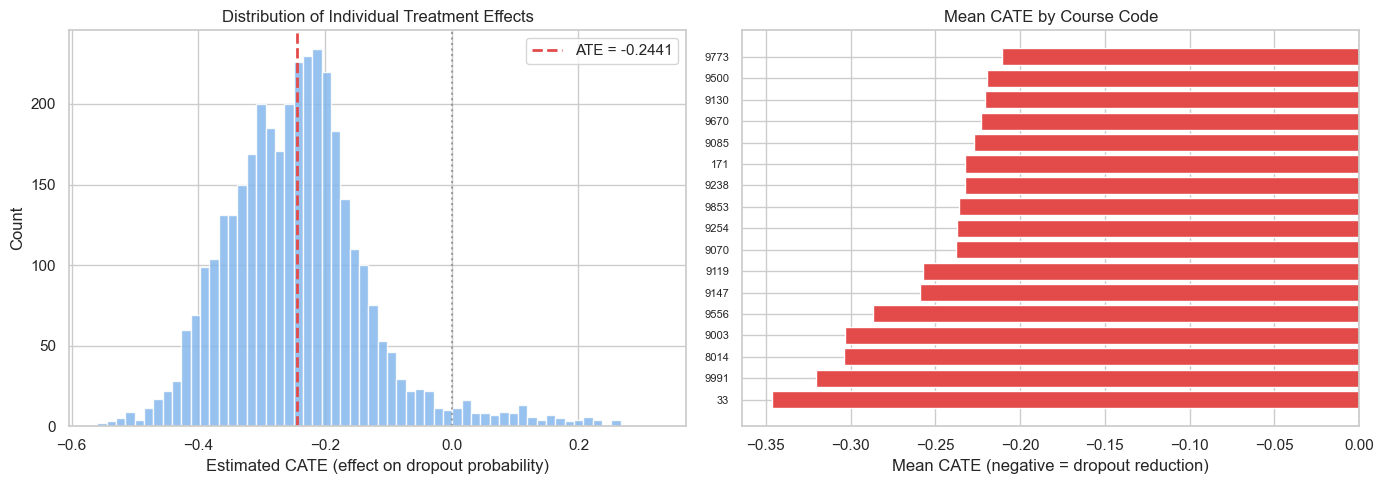

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: CATE histogram
ax = axes[0]
ax.hist(tau_hat, bins=60, color='#85B7EB', edgecolor='white', alpha=0.85)
ax.axvline(tau_hat.mean(), color='#E24B4A', linestyle='--', lw=2,
           label=f'ATE = {tau_hat.mean():+.4f}')
ax.axvline(0, color='gray', linestyle=':', lw=1.5, alpha=0.7)
ax.set_xlabel('Estimated CATE (effect on dropout probability)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Individual Treatment Effects')
ax.legend()

# Panel 2: Mean CATE by course (most negative = scholarship most effective at reducing dropout)
ax = axes[1]
cate_by_course = df_resolved.groupby('Course')['tau_hat'].mean().sort_values()
ax.barh(range(len(cate_by_course)), cate_by_course.values,
        color=['#E24B4A' if v < 0 else '#85B7EB' for v in cate_by_course.values],
        edgecolor='white')
ax.axvline(0, color='gray', linestyle=':', lw=1.2, alpha=0.7)
ax.set_yticks(range(len(cate_by_course)))
ax.set_yticklabels([str(int(c)) for c in cate_by_course.index], fontsize=8)
ax.set_xlabel('Mean CATE (negative = dropout reduction)')
ax.set_title('Mean CATE by Course Code')

plt.tight_layout()
plt.show()

## 3. Sensitivity Analysis — Confidence Intervals

We compute **90% confidence intervals** for each CATE estimate using the CausalForest's built-in honesty-based variance estimation. This shows which individual estimates are statistically distinguishable from zero.

90% CI analysis (outcome = Dropout):
  Significantly negative CATE (dropout ↓): 3171 (87.4%)
  Significantly positive CATE (dropout ↑): 9 (0.2%)
  Inconclusive (CI crosses 0):              450 (12.4%)


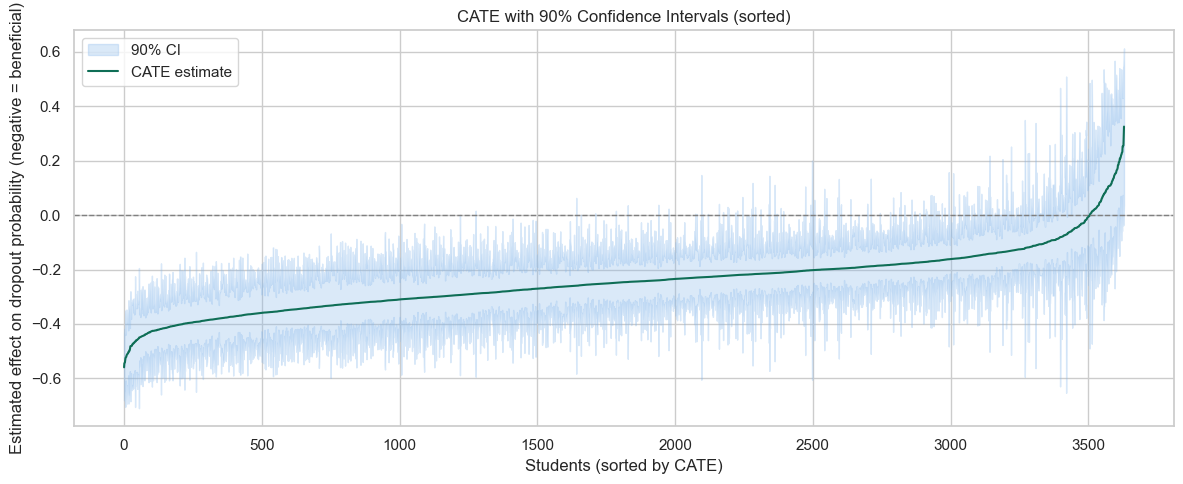

In [11]:
tau_lb, tau_ub = est.effect_interval(X_resolved, alpha=0.1)
tau_lb = tau_lb.flatten()
tau_ub = tau_ub.flatten()

sig_negative = (tau_ub < 0).sum()   # CI entirely negative = dropout reduction significant
sig_positive = (tau_lb > 0).sum()   # CI entirely positive = counter-productive
inconclusive = len(tau_hat) - sig_negative - sig_positive

print(f"90% CI analysis (outcome = Dropout):")
print(f"  Significantly negative CATE (dropout ↓): {sig_negative} ({sig_negative/len(tau_hat)*100:.1f}%)")
print(f"  Significantly positive CATE (dropout ↑): {sig_positive} ({sig_positive/len(tau_hat)*100:.1f}%)")
print(f"  Inconclusive (CI crosses 0):              {inconclusive} ({inconclusive/len(tau_hat)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(12, 5))
sorted_idx = np.argsort(tau_hat)
ax.fill_between(range(len(tau_hat)), tau_lb[sorted_idx], tau_ub[sorted_idx],
                alpha=0.3, color='#85B7EB', label='90% CI')
ax.plot(range(len(tau_hat)), tau_hat[sorted_idx], color='#0F6E56', lw=1.5, label='CATE estimate')
ax.axhline(0, color='gray', linestyle='--', lw=1)
ax.set_xlabel('Students (sorted by CATE)')
ax.set_ylabel('Estimated effect on dropout probability (negative = beneficial)')
ax.set_title('CATE with 90% Confidence Intervals (sorted)')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Policy Learning: Optimal Scholarship Assignment

### 8.1 Setup & Problem Formulation

We have CATE estimates $\hat{\tau}(W_i) < 0$ from the Causal Forest (scholarship **reduces** dropout). The goal is to find the assignment policy $\pi^*: W \to \{0, 1\}$ that **minimizes expected dropout rate**:

$$\pi^* = \arg\min_{\pi \in \Pi_B} \; \frac{1}{n}\sum_i \hat{\mu}_0(W_i) + \hat{\tau}(W_i) \cdot \pi(W_i)$$

equivalently, **assign to students with the most negative CATE** (highest marginal benefit), subject to a **budget constraint**: same total number of scholarships as currently observed ($B = \sum_i D_i$).

This is the framework of **Kitagawa & Tetenov (2018)** and **Athey & Wager (2021)**.

In [12]:
# Budget = same number of scholarships as currently observed in df_resolved
B = df_resolved[treatment].sum()
print(f"Budget constraint: {B} scholarships ({B/len(df_resolved)*100:.1f}% of resolved students)")
print(f"Observed scholarship rate: {df_resolved[treatment].mean()*100:.1f}%")

Budget constraint: 969 scholarships (26.7% of resolved students)
Observed scholarship rate: 26.7%


### 8.2 CATE-Threshold Policy (Simple Optimal Policy)

Under a budget constraint, the optimal policy is to rank students by estimated CATE (descending) and assign scholarships to the top $B$. This directly solves the optimization problem above.

In [13]:
# Rank students by CATE — most negative first (most dropout-reduction benefit)
df_resolved['rank'] = df_resolved['tau_hat'].rank(ascending=True, method='first')

# Optimal policy: bottom-B students (most negative tau) get scholarship
df_resolved['pi_star'] = (df_resolved['rank'] <= B).astype(int)

# Observed policy
df_resolved['pi_obs'] = df_resolved[treatment]

# Verify budget constraint
assert df_resolved['pi_star'].sum() == B, "Budget constraint violated!"

print(f"Optimal policy assigns {df_resolved['pi_star'].sum()} scholarships (same as observed: {df_resolved['pi_obs'].sum()})")
print(f"\nReassignment breakdown:")
print(f"  Keep scholarship (obs=1 & star=1):      {((df_resolved['pi_obs']==1)&(df_resolved['pi_star']==1)).sum()}")
print(f"  Keep no scholarship (obs=0 & star=0):   {((df_resolved['pi_obs']==0)&(df_resolved['pi_star']==0)).sum()}")
print(f"  Gain scholarship (obs=0 → star=1):      {((df_resolved['pi_obs']==0)&(df_resolved['pi_star']==1)).sum()}")
print(f"  Lose scholarship (obs=1 → star=0):      {((df_resolved['pi_obs']==1)&(df_resolved['pi_star']==0)).sum()}")

Optimal policy assigns 969 scholarships (same as observed: 969)

Reassignment breakdown:
  Keep scholarship (obs=1 & star=1):      200
  Keep no scholarship (obs=0 & star=0):   1892
  Gain scholarship (obs=0 → star=1):      769
  Lose scholarship (obs=1 → star=0):      769


### 8.3 Policy Tree — Interpretable Assignment Rules

A **policy tree** approximates the CATE-threshold policy with a shallow decision tree, providing actionable rules the polytechnic can implement without running ML models per student.

We try `econml.policy.PolicyTree` (which directly maximizes welfare) and fall back to `sklearn.tree.DecisionTreeClassifier` fitted on the `pi_star` labels.

In [14]:
X_tree = df_resolved[W_confounders].values

# PolicyTree from econml maximizes E[tau * pi]. Since tau < 0 (dropout outcome),
# it would assign 0 everywhere. We use the sklearn fallback:
# fit a DecisionTreeClassifier on pi_star labels, then re-budget.
policy_tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, random_state=42)
policy_tree.fit(X_tree, df_resolved['pi_star'])

proba_tree = policy_tree.predict_proba(X_tree)[:, 1]
# Re-budget: keep exactly B scholarships (top-B by predicted probability)
pi_tree = (pd.Series(proba_tree)
             .rank(ascending=False, method='first')
             .le(B)
             .astype(int)
             .values)

agreement = (pi_tree == df_resolved['pi_star'].values).mean()
print(f"Policy tree: {pi_tree.sum()} scholarships assigned")
print(f"Agreement with CATE-threshold policy: {agreement*100:.1f}%")

Policy tree: 969 scholarships assigned
Agreement with CATE-threshold policy: 83.7%


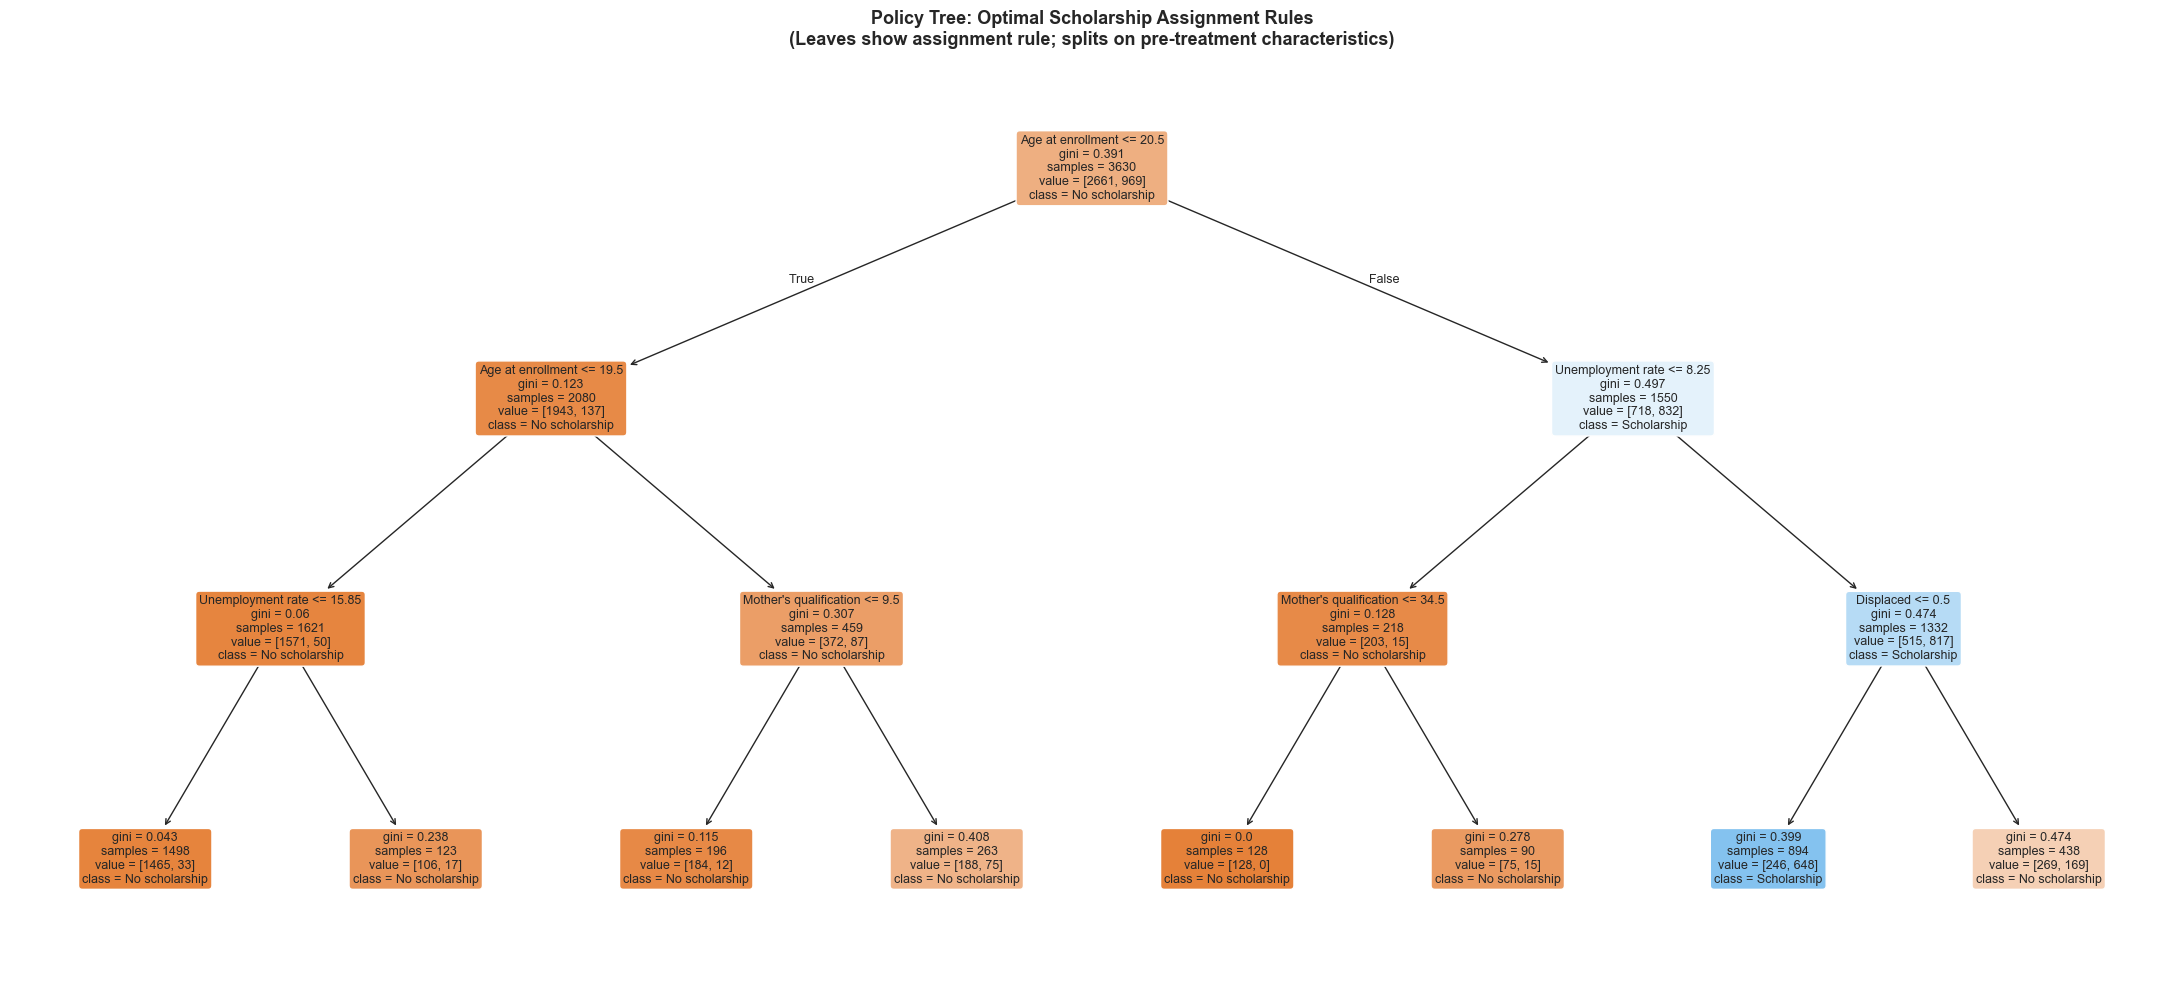

In [18]:
fig, ax = plt.subplots(figsize=(22, 10))


plot_tree(policy_tree, feature_names=W_confounders,
            class_names=['No scholarship', 'Scholarship'],
            filled=True, rounded=True, ax=ax, fontsize=9)


ax.set_title("Policy Tree: Optimal Scholarship Assignment Rules\n"
             "(Leaves show assignment rule; splits on pre-treatment characteristics)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.4 Policy Evaluation — Expected Dropout Rates

We evaluate each policy using the **CATE plug-in estimator**:

$$\hat{V}(\pi) = \frac{1}{n} \sum_i \left[\hat{\mu}_0(W_i) + \hat{\tau}(W_i) \cdot \pi(W_i)\right]$$

where $\hat{\mu}_0(W_i) = \mathbb{E}[Y_{\text{Dropout}} \mid D=0, W=W_i]$ is the **baseline dropout probability** (without scholarship), estimated on the untreated subsample.

Since $\hat{\tau} < 0$, assigning scholarships ($\pi=1$) decreases $\hat{V}(\pi)$. The optimal policy **minimizes** $\hat{V}(\pi)$.

In [ ]:
# Fit mu_0 model on untreated subsample
# Predicts P(Dropout | D=0, W) — baseline dropout probability without scholarship
untreated = df_resolved[df_resolved[treatment] == 0]
mu0_model = RandomForestClassifier(n_estimators=500, max_depth=10,
                                    random_state=42, n_jobs=-1)
mu0_model.fit(untreated[W_all], untreated['Dropout'])
mu0_hat = mu0_model.predict_proba(df_resolved[W_all])[:, 1]

print(f"mu0 model trained on {len(untreated)} untreated students")
print(f"  Mean baseline dropout prob (untreated): {mu0_hat[df_resolved[treatment]==0].mean():.3f}")
print(f"  Mean baseline dropout prob (treated):   {mu0_hat[df_resolved[treatment]==1].mean():.3f}")

mu0 model trained on 2661 untreated students
  Mean baseline dropout prob (untreated): 0.483
  Mean baseline dropout prob (treated):   0.362


In [ ]:
def expected_dropout(mu0, tau, pi):
    return np.mean(mu0 + tau * pi)

policies = {
    'No scholarships':          np.zeros(len(df_resolved)),
    'Observed assignment':      df_resolved['pi_obs'].values,
    'Optimal (CATE threshold)': df_resolved['pi_star'].values,
    'Optimal (policy tree)':    pi_tree,
}

results_pl = []
for name, pi in policies.items():
    drop_rate = expected_dropout(mu0_hat, tau_hat, pi)
    n_scholarships = int(pi.sum())
    results_pl.append({
        'Policy':                    name,
        'Scholarships assigned':     n_scholarships,
        'Scholarship rate (%)':      round(n_scholarships / len(df_resolved) * 100, 1),
        'Expected dropout rate (%)': round(drop_rate * 100, 1),
    })

results_df = pd.DataFrame(results_pl)
obs_rate = results_df.loc[results_df['Policy'] == 'Observed assignment',
                          'Expected dropout rate (%)'].values[0]
results_df['Δ vs observed (pp)'] = (results_df['Expected dropout rate (%)'] - obs_rate).round(1)

print(results_df.to_string(index=False))
print("\n(Negative Δ = improvement over observed policy)")

                  Policy  Scholarships assigned  Scholarship rate (%)  Expected dropout rate (%)  Δ vs observed (pp)
         No scholarships                      0                   0.0                       45.1                 6.5
     Observed assignment                    969                  26.7                       38.6                 0.0
Optimal (CATE threshold)                    969                  26.7                       35.2                -3.4
   Optimal (policy tree)                    969                  26.7                       35.8                -2.8

(Negative Δ = improvement over observed policy)


### 8.5 Who Gets Reassigned? Profile Analysis

We classify students into three groups based on how their scholarship status changes under the optimal policy:
- **Gain scholarship**: currently untreated, targeted by optimal policy
- **Lose scholarship**: currently treated, dropped by optimal policy
- **Keep status**: no change

Profiling these groups reveals which student characteristics drive the reallocation.

In [ ]:
df_resolved['reassignment'] = 'Keep status'
df_resolved.loc[(df_resolved['pi_obs'] == 0) & (df_resolved['pi_star'] == 1), 'reassignment'] = 'Gain scholarship'
df_resolved.loc[(df_resolved['pi_obs'] == 1) & (df_resolved['pi_star'] == 0), 'reassignment'] = 'Lose scholarship'

print(df_resolved['reassignment'].value_counts())

profile_cols = ['Course', 'Age at enrollment', 'Gender', 'Displaced',
                'Admission grade', 'Previous qualification (grade)', 'tau_hat']
profile = df_resolved.groupby('reassignment')[profile_cols].mean().round(3)
print("\nMean characteristics by reassignment group:")
print(profile)

reassignment
Keep status         2092
Gain scholarship     769
Lose scholarship     769
Name: count, dtype: int64

Mean characteristics by reassignment group:
                    Course  Age at enrollment  Gender  Displaced  \
reassignment                                                       
Gain scholarship  8931.082             30.251   0.467      0.233   
Keep status       8808.310             22.432   0.362      0.609   
Lose scholarship  8901.125             19.471   0.172      0.704   

                  Admission grade  Previous qualification (grade)  tau_hat  
reassignment                                                                
Gain scholarship          126.093                         130.771   -0.369  
Keep status               127.517                         133.067   -0.211  
Lose scholarship          127.887                         134.673   -0.209  


### 8.6 Reallocation by Course — Key Visualization

The chart below compares scholarship rates by study programme under the observed vs. optimal policy. Programmes are sorted by their observed dropout rate (highest at top) — high-dropout programmes where the scholarship has large treatment effects receive more scholarships under the optimal policy.

The optimal policy **reallocates scholarships from courses with low dropout** (where scholarships have little marginal impact) **toward courses with high dropout and high treatment effect** (where scholarships are most impactful). This suggests the current means-tested allocation is suboptimal from a dropout-minimization perspective.

Course codes in df_resolved: [np.int64(33), np.int64(171), np.int64(8014), np.int64(9003), np.int64(9070), np.int64(9085), np.int64(9119), np.int64(9130), np.int64(9147), np.int64(9238), np.int64(9254), np.int64(9500), np.int64(9556), np.int64(9670), np.int64(9773), np.int64(9853), np.int64(9991)]


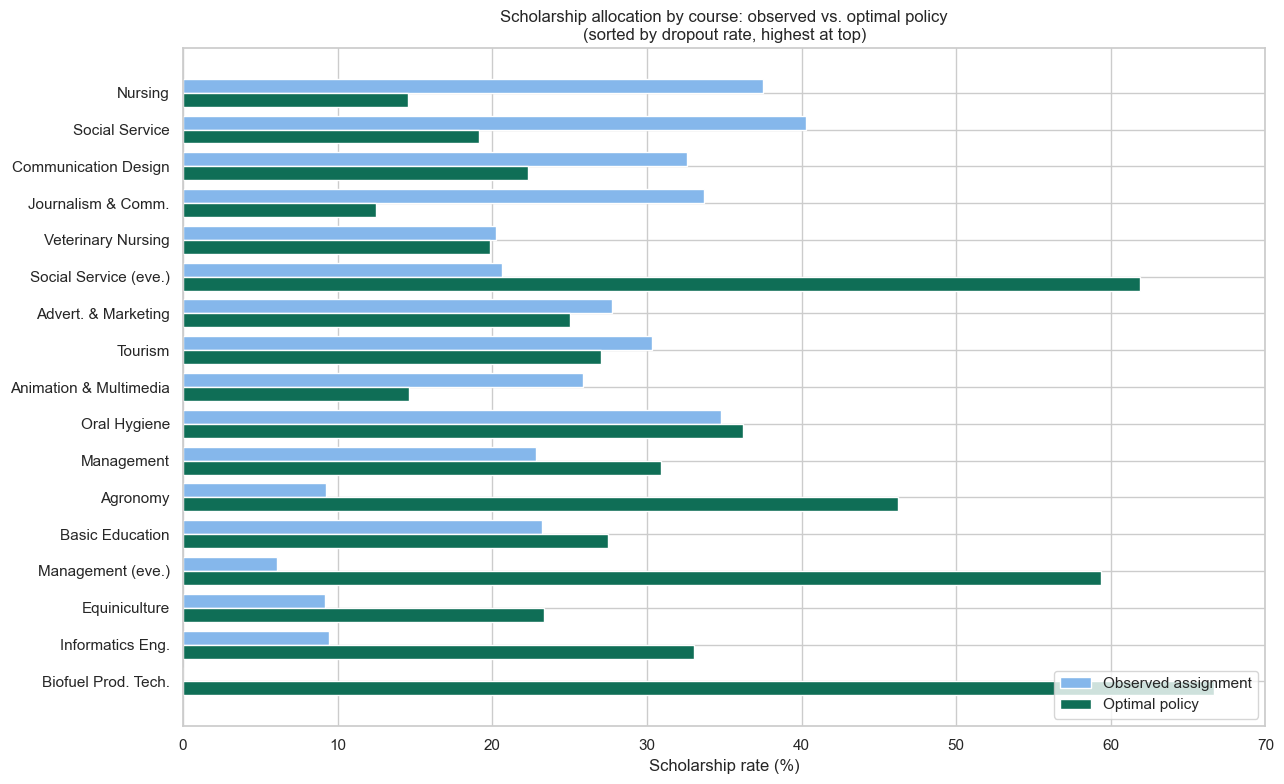

In [ ]:
# Check actual course codes in the data
print("Course codes in df_resolved:", sorted(df_resolved['Course'].unique()))

course_names = {
    33:   'Biofuel Prod. Tech.',
    171:  'Animation & Multimedia',
    8014: 'Social Service (eve.)',
    9003: 'Agronomy',
    9070: 'Communication Design',
    9085: 'Veterinary Nursing',
    9119: 'Informatics Eng.',
    9130: 'Equiniculture',
    9147: 'Management',
    9238: 'Social Service',
    9254: 'Tourism',
    9500: 'Nursing',
    9556: 'Oral Hygiene',
    9670: 'Advert. & Marketing',
    9773: 'Journalism & Comm.',
    9853: 'Basic Education',
    9991: 'Management (eve.)',
}
df_resolved['Course_name'] = (df_resolved['Course']
                               .map(course_names)
                               .fillna(df_resolved['Course'].astype(str)))

course_comparison = (df_resolved
    .groupby('Course_name')
    .agg(
        obs_rate=('pi_obs', 'mean'),
        optimal_rate=('pi_star', 'mean'),
        dropout_rate_obs=('Dropout', 'mean'),
        n_students=('Dropout', 'count'),
        mean_tau=('tau_hat', 'mean'),
    )
    .sort_values('dropout_rate_obs', ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 8))
x = np.arange(len(course_comparison))
width = 0.38

bars1 = ax.barh(x + width/2, course_comparison['obs_rate'] * 100, width,
                label='Observed assignment', color='#85B7EB')
bars2 = ax.barh(x - width/2, course_comparison['optimal_rate'] * 100, width,
                label='Optimal policy', color='#0F6E56')

ax.set_xlabel('Scholarship rate (%)')
ax.set_yticks(x)
ax.set_yticklabels(course_comparison['Course_name'])
ax.legend(loc='lower right')
ax.set_title('Scholarship allocation by course: observed vs. optimal policy\n'
             '(sorted by dropout rate, highest at top)', fontsize=12)
plt.tight_layout()
plt.show()

### 8.7 Applying the Optimal Policy to Currently Enrolled Students

The `df_enrolled` sample (~794 students) is still studying — their final outcome is unknown. We use the fitted CausalForest to predict their CATE and design an optimal scholarship allocation under a proportional budget (same scholarship rate as observed in `df_resolved`).

In [ ]:
X_enrolled = df_enrolled[W_confounders].values
tau_enrolled = est.effect(X_enrolled).flatten()
mu0_enrolled = mu0_model.predict_proba(df_enrolled[W_all])[:, 1]

df_enrolled = df_enrolled.copy()
df_enrolled['tau_hat'] = tau_enrolled

# Budget for enrolled: same scholarship rate as observed in df_resolved
scholarship_rate = df_resolved[treatment].mean()
B_enrolled = int(len(df_enrolled) * scholarship_rate)

# Assign to students with most negative CATE (ascending rank)
df_enrolled['rank'] = df_enrolled['tau_hat'].rank(ascending=True, method='first')
df_enrolled['pi_star'] = (df_enrolled['rank'] <= B_enrolled).astype(int)
df_enrolled['pi_obs']  = df_enrolled[treatment]

dropout_none    = expected_dropout(mu0_enrolled, tau_enrolled, np.zeros(len(df_enrolled)))
dropout_obs     = expected_dropout(mu0_enrolled, tau_enrolled, df_enrolled['pi_obs'].values)
dropout_optimal = expected_dropout(mu0_enrolled, tau_enrolled, df_enrolled['pi_star'].values)

print(f"Expected dropout rate among Enrolled students:")
print(f"  No scholarships:      {dropout_none*100:.1f}%")
print(f"  Current assignment:   {dropout_obs*100:.1f}%")
print(f"  Optimal assignment:   {dropout_optimal*100:.1f}%")
print(f"  Improvement:          {(dropout_obs - dropout_optimal)*100:.1f} pp dropout reduction")

Expected dropout rate among Enrolled students:
  No scholarships:      46.1%
  Current assignment:   41.9%
  Optimal assignment:   36.5%
  Improvement:          5.5 pp dropout reduction


### 8.8 Summary Visualization

Three-panel figure synthesizing all policy learning results:
1. **CATE distribution** with the budget threshold (who is at the margin)
2. **Reallocation** by course — top 8 courses with largest absolute change in scholarship rate
3. **Expected dropout** comparison for enrolled students under three policies

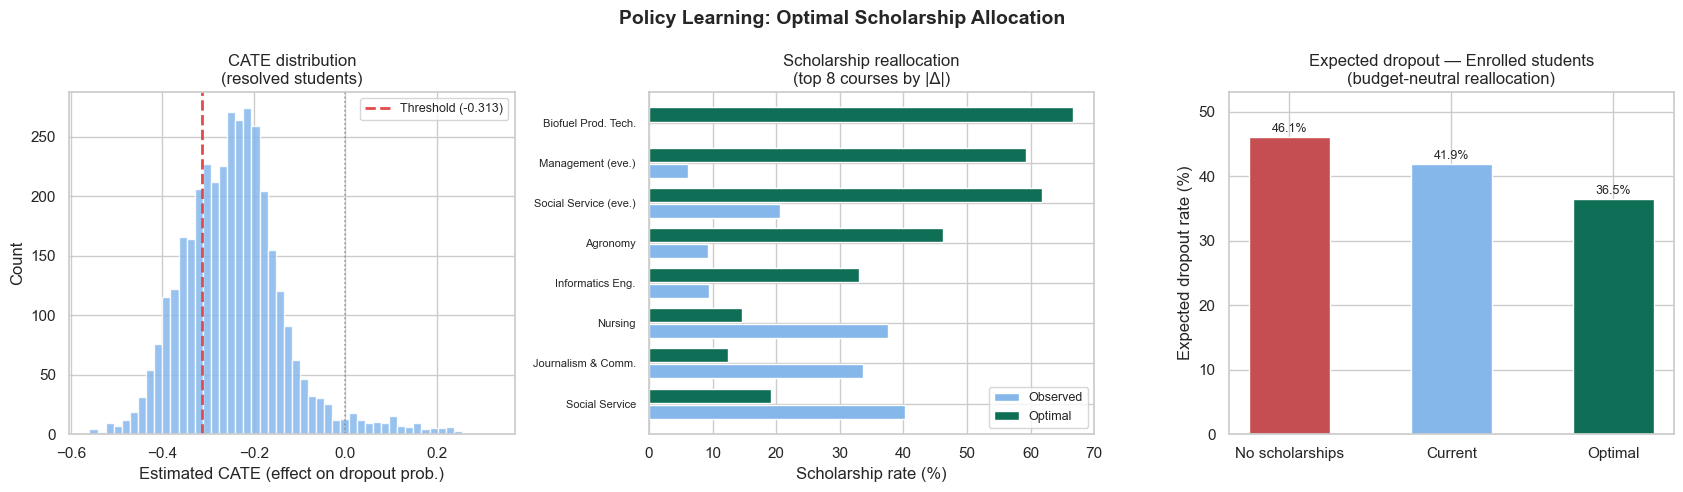

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Policy Learning: Optimal Scholarship Allocation', fontsize=14, fontweight='bold')

# Panel 1: CATE distribution with budget threshold
ax = axes[0]
threshold = np.sort(tau_hat)[B - 1]   # ascending: B-th most negative
ax.hist(tau_hat, bins=50, color='#85B7EB', edgecolor='white', alpha=0.85)
ax.axvline(threshold, color='#E24B4A', linestyle='--', lw=2,
           label=f'Threshold ({threshold:.3f})')
ax.axvline(0, color='gray', linestyle=':', lw=1.2, alpha=0.7)
ax.set_xlabel('Estimated CATE (effect on dropout prob.)')
ax.set_ylabel('Count')
ax.set_title('CATE distribution\n(resolved students)')
ax.legend(fontsize=9)

# Panel 2: Top 8 courses with largest reallocation
ax = axes[1]
course_grp = df_resolved.groupby('Course').agg(
    obs_rate=('pi_obs', 'mean'),
    opt_rate=('pi_star', 'mean'),
    n=('pi_obs', 'size'),
).reset_index()
course_grp['delta'] = (course_grp['opt_rate'] - course_grp['obs_rate']).abs()
top8 = course_grp.nlargest(8, 'delta').sort_values('delta')
labels = [course_names.get(int(c), str(int(c))) for c in top8['Course']]
y = np.arange(len(top8))
ax.barh(y - 0.2, top8['obs_rate'] * 100, 0.35, label='Observed', color='#85B7EB')
ax.barh(y + 0.2, top8['opt_rate'] * 100, 0.35, label='Optimal',  color='#0F6E56')
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Scholarship rate (%)')
ax.set_title('Scholarship reallocation\n(top 8 courses by |Δ|)')
ax.legend(fontsize=9)

# Panel 3: Expected dropout comparison for enrolled
ax = axes[2]
scenarios = ['No scholarships', 'Current', 'Optimal']
rates = [dropout_none * 100, dropout_obs * 100, dropout_optimal * 100]
colors = ['#C44E52', '#85B7EB', '#0F6E56']
bars = ax.bar(scenarios, rates, color=colors, edgecolor='white', width=0.5)
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{rate:.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Expected dropout rate (%)')
ax.set_title('Expected dropout — Enrolled students\n(budget-neutral reallocation)')
ax.set_ylim(0, max(rates) * 1.15)

plt.tight_layout()
plt.show()